In [1]:
%cd ../..
%load_ext autoreload
%autoreload 2

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/vlms4rehab


In [2]:
import json
import re
from pathlib import Path
from typing import Iterable, List, Dict, Any, Set, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --------------------------
# 1) FINAL_ANSWER parser (unchanged)
# --------------------------
FINAL_ANSWER_RE = re.compile(
    r'(?mi)FINAL_ANSWER\s*:\s*([^\n<]+)',
    re.MULTILINE,
)

def _parse_final_answer(text: str, allowed_labels: Set[str] | None = None) -> str:
    if not text:
        return ""
    m = FINAL_ANSWER_RE.search(text)
    if not m:
        return ""
    val = m.group(1).strip()
    if len(val) >= 2:
        pairs = {('"', '"'), ("'", "'"), ('`', '`'), ('“', '”'), ('‘', '’')}
        for lq, rq in pairs:
            if val.startswith(lq) and val.endswith(rq):
                val = val[1:-1].strip()
                break
    val = val.rstrip(" .;:,`'\"")
    if allowed_labels is not None and val not in allowed_labels:
        return ""
    return val

# --------------------------
# 2) Ground-truth normalization
# --------------------------
_RTT_SIDE_RE   = re.compile(r'^\s*RTT\s+(left|right)\s+side\b', re.IGNORECASE)
_SHELF_SIDE_RE = re.compile(r'^\s*shelf\s+(left|right)\s+side\b', re.IGNORECASE)

def normalize_true_activity(activity: str) -> str:
    """
    Map:
      - 'RTT left side' / 'RTT right side' -> 'RTT exercise'
      - 'shelf left side' / 'shelf right side' -> 'Shelf exercise'
    Otherwise, return original.
    """
    if not isinstance(activity, str):
        return activity
    if _RTT_SIDE_RE.search(activity):
        return "RTT exercise"
    if _SHELF_SIDE_RE.search(activity):
        return "Shelf exercise"
    return activity

# --------------------------
# 3) Helpers to read/flatten
# --------------------------
def _safe_json_loads(s: str) -> Any:
    try:
        return json.loads(s)
    except Exception:
        return None

def _flatten_resps(rec: Dict[str, Any]) -> List[str]:
    out: List[str] = []
    filt = rec.get("filtered_resps")
    if isinstance(filt, list):
        out.extend([str(x) for x in filt])
    if not out:
        def _walk(x):
            if isinstance(x, str):
                out.append(x)
            elif isinstance(x, (list, tuple)):
                for y in x:
                    _walk(y)
            elif isinstance(x, dict):
                for v in x.values():
                    _walk(v)
        _walk(rec.get("resps"))
    return out

# --------------------------
# 4) Prediction extraction with whitelist + 'Other'
# --------------------------
def extract_prediction_with_other(
    rec: Dict[str, Any],
) -> str:
    """
    Extract FINAL_ANSWER from any response text.
    """
    s = _flatten_resps(rec)[0]
    pred = _parse_final_answer(s, allowed_labels=None)  # parse first
    return pred

# --------------------------
# 5) Load records + build DF (now with label list + normalization)
# --------------------------
def load_log_records(path: str | Path) -> List[Dict[str, Any]]:
    p = Path(path)
    text = p.read_text(encoding="utf-8").strip()
    if "\n" in text:
        records = []
        for line in text.splitlines():
            line = line.strip()
            if not line:
                continue
            obj = _safe_json_loads(line)
            if isinstance(obj, dict):
                records.append(obj)
        if records:
            return records
    obj = _safe_json_loads(text)
    if isinstance(obj, dict):
        return [obj]
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    return []

def build_predictions_dataframe(
    records: List[Dict[str, Any]],
    *,
    label_list: Optional[List[str]] = None,   # <- your whitelist
) -> pd.DataFrame:
    allowed = set(label_list) if label_list is not None else None

    rows: List[Dict[str, Any]] = []
    for r in records:
        doc = r.get("doc", {}) or {}
        activity_true = normalize_true_activity(doc.get("activity", ""))
        pred = extract_prediction_with_other(r)
        rows.append(
            {
                "id":        doc.get("id", ""),
                "path_v":    doc.get("path_v", ""),
                "patient":   doc.get("patient", ""),
                "activity":  activity_true,   # normalized ground truth
                "pred_activity": pred,        # whitelisted or 'Other'
            }
        )
    df = pd.DataFrame(rows)
    df['activity'] = df['activity'].str.lower().str.strip()
    df['pred_activity'] = df['pred_activity'].str.lower().str.strip()
    df['activity'] = df['activity'].map(lambda x: 'deodorant' if x == 'deodrant' else x)
    df['pred_activity'] = df['pred_activity'].map(lambda x: x if x in allowed else 'none')
    df['stroke'] = df['patient'].str.contains('s', case=False, na=False)
    return df

# --------------------------
# 6) Confusion matrix (ensure labels + Other appear)
# --------------------------
def plot_confusion_matrix_from_df(
    df: pd.DataFrame,
    true_col: str = "activity",
    pred_col: str = "pred_activity",
    *,
    label_order: Optional[List[str]] = None,
    include_other: bool = True,
    other_label: str = "Other",
    normalize: bool = True,
    title: str = "Activity Confusion Matrix",
    rotate_xticks: int = 45,
    cmap: str = "Blues",   # better contrast
) -> Tuple[np.ndarray, List[str]]:
    assert true_col in df.columns and pred_col in df.columns, "Missing required columns."

    if label_order is None:
        labels = sorted(set(df[true_col].astype(str)) | set(df[pred_col].astype(str)))
    else:
        labels = list(label_order)

    if include_other and other_label not in labels and (df[pred_col] == other_label).any():
        labels = labels + [other_label]

    y_true = df[true_col].astype(str).values
    y_pred = df[pred_col].astype(str).values

    cm_counts = confusion_matrix(y_true, y_pred, labels=labels)
    cm = cm_counts.astype(float)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            cm = np.where(row_sums > 0, cm / row_sums, 0.0)

    n = len(labels)
    fig_size = max(6, min(1.0 * n, 18))
    plt.figure(figsize=(fig_size, fig_size))
    im = plt.imshow(cm, interpolation="nearest", cmap=cmap)
    # plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.xticks(ticks=np.arange(n), labels=labels, rotation=rotate_xticks, ha="right")
    plt.yticks(ticks=np.arange(n), labels=labels)

    # --- annotate with adaptive text color ---
    thresh = cm.max() / 2.0
    for i in range(n):
        for j in range(n):
            count = cm_counts[i, j]
            if normalize:
                pct = cm[i, j] * 100.0
                text = f"{count}\n({pct:.0f}%)" if count > 0 else ""
            else:
                text = f"{count}" if count > 0 else ""
            if text:
                color = "white" if cm[i, j] > thresh else "black"
                plt.text(j, i, text, va="center", ha="center", color=color, fontsize=10, weight="bold")

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return cm_counts, labels

In [3]:
log_files_direct = {
    "qwen2_5_vl_7b": "logs/strokerehab_identification_1/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct/20251028_000553_samples_strokerehab_identification_1.jsonl",
}

log_files_tuned = {
    "qwen2_5_vl_7b": "logs/strokerehab_identification_2/qwen2_5_vl_7b/Qwen__Qwen2.5-VL-7B-Instruct/20251021_031935_samples_strokerehab_identification.jsonl",
    "qwen2_5_vl_32b": "logs/strokerehab_identification_2/qwen2_5_vl_32b/Qwen__Qwen2.5-VL-32B-Instruct/20251021_211532_samples_strokerehab_identification.jsonl",
    "qwen2_5_vl_72b": "logs/strokerehab_identification_2/qwen2_5_vl_72b/Qwen__Qwen2.5-VL-72B-Instruct/20251021_211606_samples_strokerehab_identification.jsonl",
}

In [4]:
exercises = [
    "brushing",
    "combing",
    "deodorant",
    "drinking",
    "face wash",
    "feeding",
    "glasses",
    "rtt exercise",
    "shelf exercise",
]

dfs_direct = {}
for model_name, log_file in log_files_direct.items():
    records = load_log_records(log_file)
    df = build_predictions_dataframe(records, label_list=exercises)
    # Take out C00015 and C00020 (prompt-tuned)
    df = df[~df['patient'].isin(['C00015', 'C00020'])]
    dfs_direct[model_name] = df

dfs_tuned = {}
for model_name, log_file in log_files_tuned.items():
    records = load_log_records(log_file)
    df = build_predictions_dataframe(records, label_list=exercises)
    # Take out C00015 and C00020 (prompt-tuned)
    df = df[~df['patient'].isin(['C00015', 'C00020'])]
    dfs_tuned[model_name] = df

In [5]:
print(len(dfs_direct['qwen2_5_vl_7b']), len(dfs_tuned['qwen2_5_vl_7b']))

640 640


In [6]:
print("Acc: {:.2f}%".format(100 * df['pred_activity'].eq(df['activity']).mean()))

Acc: 64.69%


In [7]:
from sklearn.metrics import classification_report

for model_name, df in dfs_tuned.items():
    print(f"=== Model: {model_name} ===")
    print(classification_report(df['activity'], df['pred_activity'], zero_division=0))

=== Model: qwen2_5_vl_7b ===
                precision    recall  f1-score   support

      brushing       0.97      0.46      0.63        67
       combing       0.68      0.22      0.33        68
     deodorant       0.90      0.76      0.83        68
      drinking       0.97      0.82      0.89        68
     face wash       0.77      0.90      0.83        67
       feeding       0.97      0.94      0.95        67
       glasses       0.92      0.85      0.88        67
          none       0.00      0.00      0.00         0
  rtt exercise       0.48      1.00      0.65        86
shelf exercise       0.99      0.93      0.96        82

      accuracy                           0.78       640
     macro avg       0.76      0.69      0.69       640
  weighted avg       0.84      0.78      0.77       640

=== Model: qwen2_5_vl_32b ===
                precision    recall  f1-score   support

      brushing       0.98      0.61      0.75        67
       combing       0.00      0.00      

In [8]:
df['activity'].value_counts().iloc[0] / len(df)

0.134375

In [9]:
len(dfs_direct)

1

In [10]:
from sklearn.metrics import accuracy_score

rows = []
for model_name, df in dfs_tuned.items():
    acc = accuracy_score(df['activity'], df['pred_activity'])
    # Escape underscores for LaTeX
    safe_name = model_name.replace("_", "\\_")
    optimized = "Optimized"
    rows.append((safe_name, acc, optimized))

for model_name, df in dfs_direct.items():
    acc = accuracy_score(df['activity'], df['pred_activity'])
    # Escape underscores for LaTeX
    safe_name = model_name.replace("_", "\\_")
    optimized = "Basic"
    rows.append((safe_name, acc, optimized))


# Print LaTeX table
print("\\begin{tabular}{l c c}")
print("\\toprule")
print("Model & Prompt & Accuracy \\\\")
print("\\midrule")
for model, acc, optimized in rows:
    print(f"{model} & {optimized} & {acc:.3f} \\\\")
print(f"majority class frequency & {df['activity'].value_counts().iloc[0] / len(df):.3f} \\\\")
print("\\bottomrule")
print("\\end{tabular}")

\begin{tabular}{l c c}
\toprule
Model & Prompt & Accuracy \\
\midrule
qwen2\_5\_vl\_7b & Optimized & 0.775 \\
qwen2\_5\_vl\_32b & Optimized & 0.564 \\
qwen2\_5\_vl\_72b & Optimized & 0.647 \\
qwen2\_5\_vl\_7b & Basic & 0.534 \\
majority class frequency & 0.134 \\
\bottomrule
\end{tabular}


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import List, Optional, Tuple
from sklearn.metrics import confusion_matrix
from matplotlib import gridspec


def plot_confusion_matrix_from_df(
    df: pd.DataFrame,
    true_col: str = "activity",
    pred_col: str = "pred_activity",
    *,
    label_order: Optional[List[str]] = None,
    include_other: bool = True,
    other_label: str = "Other",
    normalize: bool = True,
    title: str = "Activity Confusion Matrix",
    rotate_xticks: int = 45,
    cmap: str = "Blues",
    save_fig: Optional[str] = None,   # NEW: save path (e.g. "cm_plot.png")
    show_ylabel: bool = True,
    show_colorbar: bool = True,
) -> Tuple[np.ndarray, List[str]]:
    """
    Plot and optionally save a confusion matrix from a DataFrame.

    Args:
        df: DataFrame with true and predicted labels.
        true_col: Column containing ground truth labels.
        pred_col: Column containing predicted labels.
        label_order: Custom order for labels (default: inferred from data).
        include_other: Whether to include 'Other' label if present.
        other_label: Label name to treat as 'Other'.
        normalize: Whether to normalize each row by its sum.
        title: Plot title.
        rotate_xticks: Degrees to rotate x-axis tick labels.
        cmap: Matplotlib colormap.
        save_fig: Path to save figure (e.g. "figures/cm.png").
        show_ylabel: Whether to show the y-axis label ("True").
        show_colorbar: Whether to render the colorbar.
    """

    assert true_col in df.columns and pred_col in df.columns, "Missing required columns."

    # ----- labels -----
    if label_order is None:
        labels = sorted(set(df[true_col].astype(str)) | set(df[pred_col].astype(str)))
    else:
        labels = list(label_order)

    if include_other and other_label not in labels and (df[pred_col] == other_label).any():
        labels.append(other_label)

    y_true = df[true_col].astype(str).values
    y_pred = df[pred_col].astype(str).values

    # counts (drop last row from display area as in original)
    cm_counts = confusion_matrix(y_true, y_pred, labels=labels)
    cm_counts = cm_counts[:-1, :]  # keep return behavior identical
    cm = cm_counts.astype(float)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            cm = np.where(row_sums > 0, cm / row_sums, 0.0)

    # ----- figure / axes with reserved colorbar column -----
    n = len(labels)
    fig_size = max(6, min(1.0 * n, 18))

    fig = plt.figure(figsize=(fig_size, fig_size))
    # Reserve a narrow column for cbar regardless of whether we show it.
    gs = gridspec.GridSpec(1, 2, width_ratios=[20, 1], figure=fig, wspace=0.08)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    # ----- image -----
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)

    ax.set_xlabel("Predicted", fontsize=24, labelpad=10)
    if show_ylabel:
        ax.set_ylabel("True", fontsize=24, labelpad=10)
    else:
        ax.set_ylabel("", fontsize=24, labelpad=10)

    ax.set_xticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=rotate_xticks, ha="right", fontsize=20)
    ax.set_yticks(np.arange(n - 1))
    ax.set_yticklabels(labels[:-1], fontsize=20)

    # ----- annotations with adaptive color -----
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(n - 1):
        for j in range(n):
            count = cm_counts[i, j]
            if normalize:
                pct = cm[i, j] * 100.0
                text = f"{pct:.0f}%" if count > 0 else ""
            else:
                text = f"{count}" if count > 0 else ""
            if text:
                color = "white" if cm[i, j] > thresh else "black"
                ax.text(j, i, text, va="center", ha="center",
                        color=color, fontsize=16, weight="bold")

    # ----- colorbar area stays fixed -----
    if show_colorbar:
        cbar = fig.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=16)
    else:
        cax.axis("off")

    fig.tight_layout()

    # ----- save / show -----
    if save_fig:
        fig.savefig(save_fig, bbox_inches="tight", dpi=300)
        print(f"Saved confusion matrix to {save_fig}")

    plt.show()
    print(f"Total counts: {cm_counts.sum()}")
    return cm_counts, labels

                       id                               path_v patient       activity  pred_activity  stroke
  C00011_RTT left side1_1   C00011/C00011_RTT left side1_1.avi  C00011   rtt exercise   rtt exercise   False
 C00011_RTT right side1_1  C00011/C00011_RTT right side1_1.avi  C00011   rtt exercise   rtt exercise   False
       C00011_brushing1_1        C00011/C00011_brushing1_1.mkv  C00011       brushing       drinking   False
        C00011_combing1_1         C00011/C00011_combing1_1.mkv  C00011        combing   rtt exercise   False
       C00011_deodrant1_1        C00011/C00011_deodrant1_1.mkv  C00011      deodorant      deodorant   False
       C00011_drinking1_1        C00011/C00011_drinking1_1.mkv  C00011       drinking       drinking   False
      C00011_face wash1_1       C00011/C00011_face wash1_1.mkv  C00011      face wash      face wash   False
        C00011_feeding1_1         C00011/C00011_feeding1_1.mkv  C00011        feeding        feeding   False
        C00011_glas

/tmp/ipykernel_3464111/2880301270.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved confusion matrix to identification_cm_qwen2_5_vl_7b_tuned.pdf


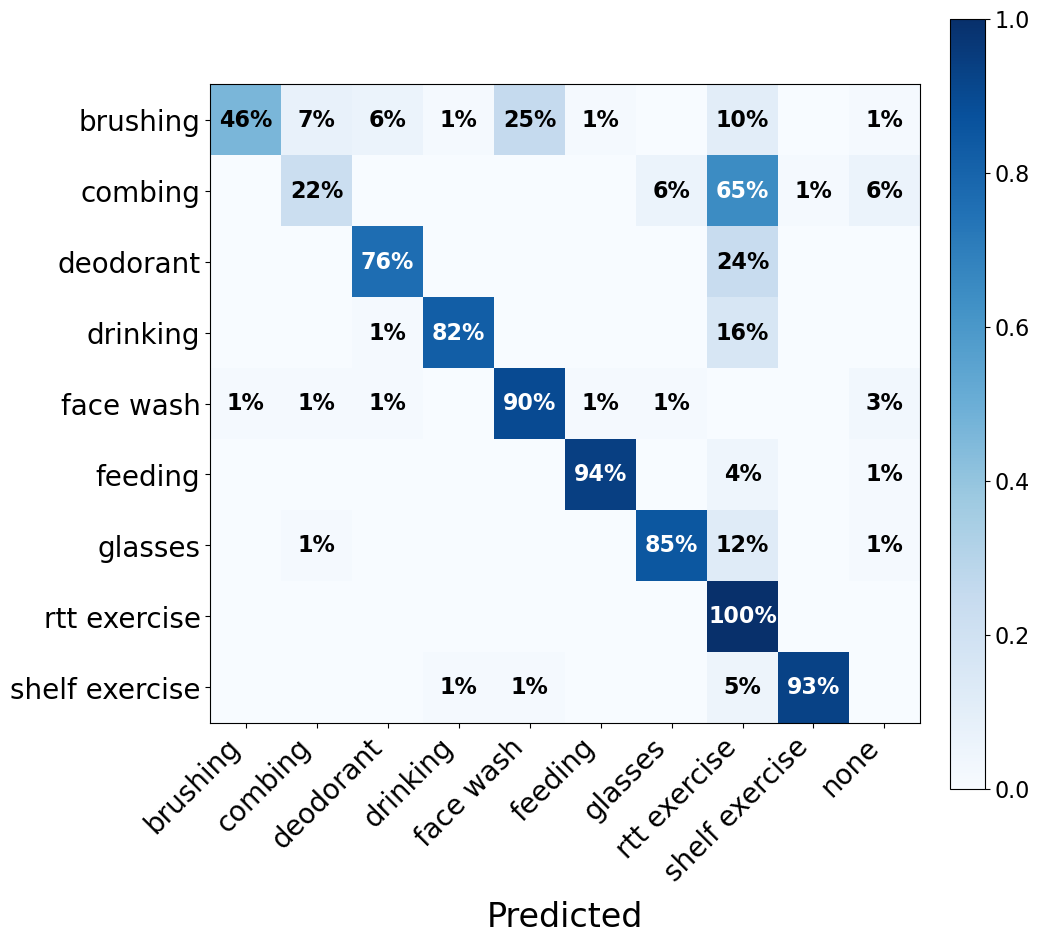

Total counts: 640


(array([[31,  5,  4,  1, 17,  1,  0,  7,  0,  1],
        [ 0, 15,  0,  0,  0,  0,  4, 44,  1,  4],
        [ 0,  0, 52,  0,  0,  0,  0, 16,  0,  0],
        [ 0,  0,  1, 56,  0,  0,  0, 11,  0,  0],
        [ 1,  1,  1,  0, 60,  1,  1,  0,  0,  2],
        [ 0,  0,  0,  0,  0, 63,  0,  3,  0,  1],
        [ 0,  1,  0,  0,  0,  0, 57,  8,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 86,  0,  0],
        [ 0,  0,  0,  1,  1,  0,  0,  4, 76,  0]]),
 ['brushing',
  'combing',
  'deodorant',
  'drinking',
  'face wash',
  'feeding',
  'glasses',
  'rtt exercise',
  'shelf exercise',
  'none'])

In [12]:

print(dfs_tuned['qwen2_5_vl_7b'].head(10).to_string(index=False))

plot_confusion_matrix_from_df(
    dfs_tuned['qwen2_5_vl_7b'],
    true_col="activity",
    pred_col="pred_activity",
    label_order=exercises + ['none'],
    normalize=True,
    title="Tailored Prompt",
    rotate_xticks=45,
    save_fig="identification_cm_qwen2_5_vl_7b_tuned.pdf",
    show_ylabel=False
)

/tmp/ipykernel_3464111/2880301270.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved confusion matrix to identification_cm_qwen2_5_vl_7b_direct.pdf


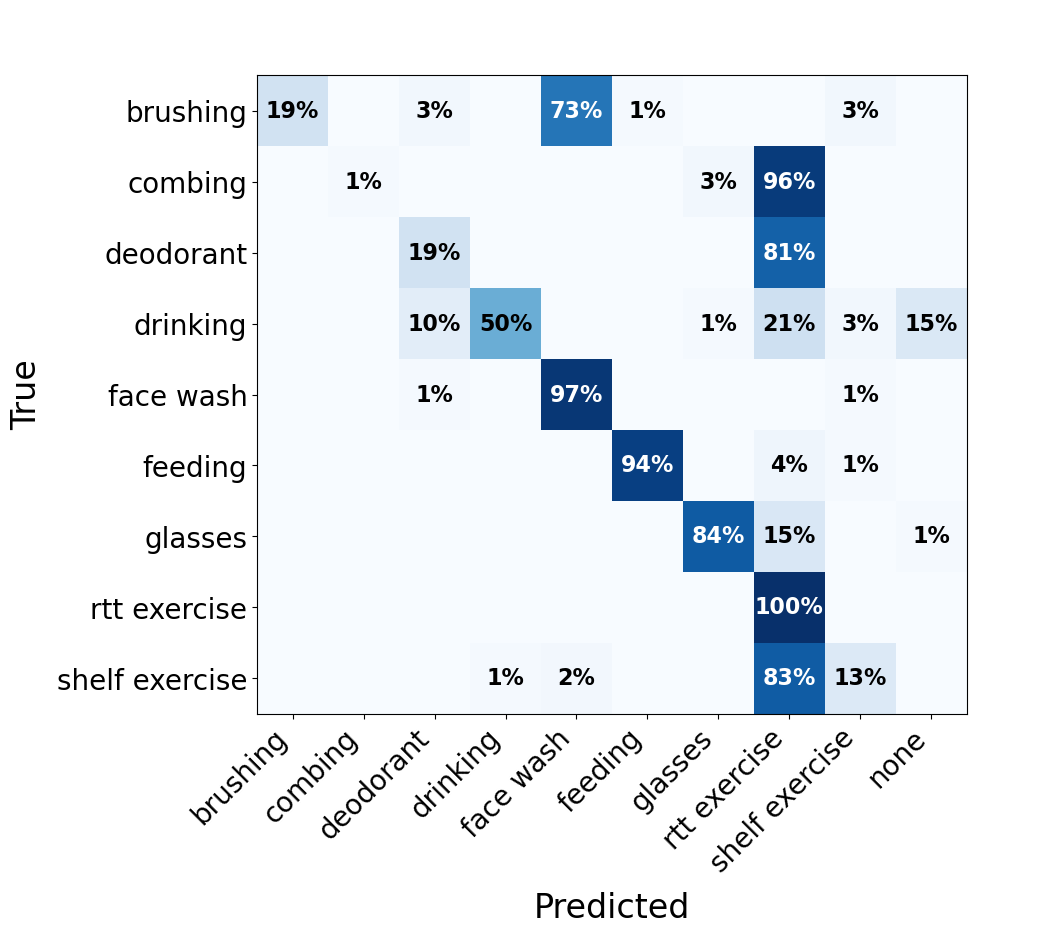

Total counts: 640


(array([[13,  0,  2,  0, 49,  1,  0,  0,  2,  0],
        [ 0,  1,  0,  0,  0,  0,  2, 65,  0,  0],
        [ 0,  0, 13,  0,  0,  0,  0, 55,  0,  0],
        [ 0,  0,  7, 34,  0,  0,  1, 14,  2, 10],
        [ 0,  0,  1,  0, 65,  0,  0,  0,  1,  0],
        [ 0,  0,  0,  0,  0, 63,  0,  3,  1,  0],
        [ 0,  0,  0,  0,  0,  0, 56, 10,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 86,  0,  0],
        [ 0,  0,  0,  1,  2,  0,  0, 68, 11,  0]]),
 ['brushing',
  'combing',
  'deodorant',
  'drinking',
  'face wash',
  'feeding',
  'glasses',
  'rtt exercise',
  'shelf exercise',
  'none'])

In [13]:
plot_confusion_matrix_from_df(
    dfs_direct['qwen2_5_vl_7b'],
    true_col="activity",
    pred_col="pred_activity",
    label_order=exercises + ['none'],
    normalize=True,
    title="Direct Prompt",
    rotate_xticks=45,
    save_fig="identification_cm_qwen2_5_vl_7b_direct.pdf",
    show_colorbar=False
)

In [14]:
df_tuned_7b = dfs_tuned['qwen2_5_vl_7b']
df_control = df_tuned_7b[~df_tuned_7b['stroke']]
df_stroke = df_tuned_7b[df_tuned_7b['stroke']]
print(f"Control videos: {len(df_control)}")
print(f"Stroke videos:  {len(df_stroke)}")
print(f"Total:          {len(df_control) + len(df_stroke)}")

Control videos: 188
Stroke videos:  452
Total:          640


/tmp/ipykernel_3464111/2880301270.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved confusion matrix to identification_cm_qwen2_5_vl_7b_tuned_control.pdf


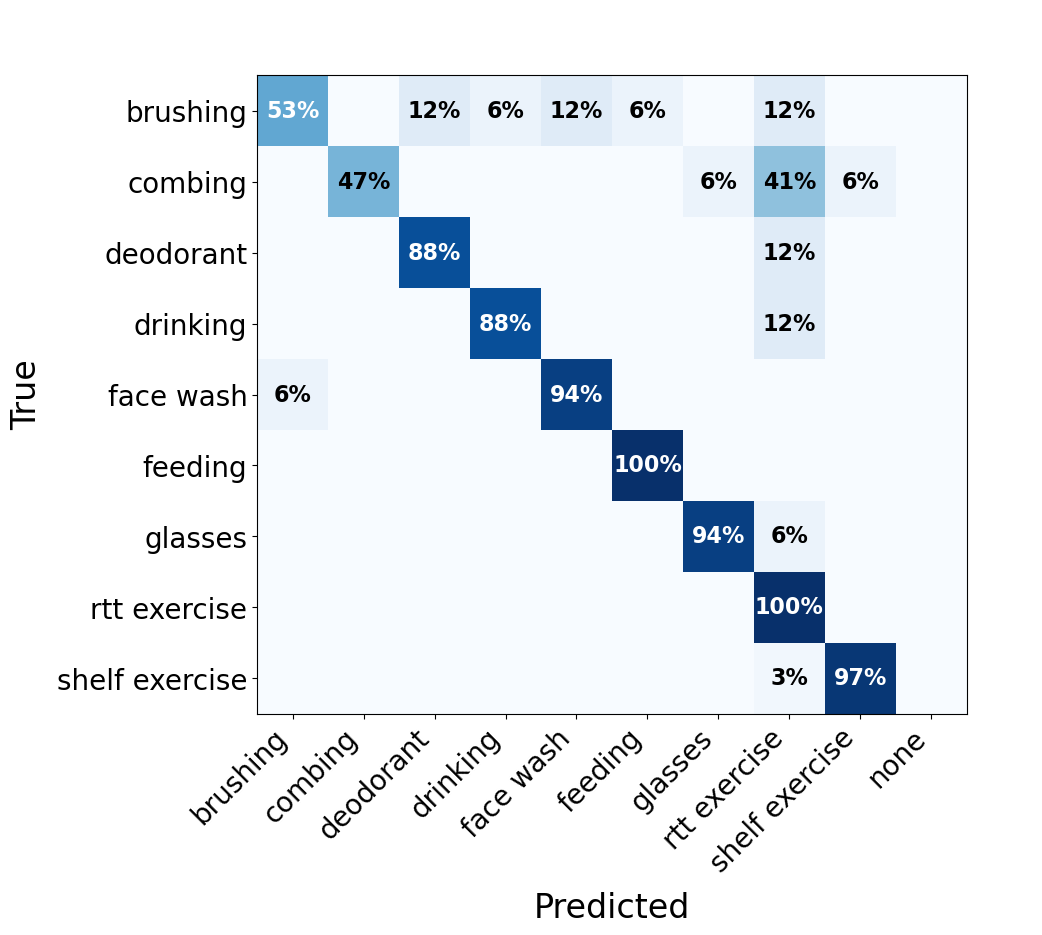

Total counts: 188


(array([[ 9,  0,  2,  1,  2,  1,  0,  2,  0,  0],
        [ 0,  8,  0,  0,  0,  0,  1,  7,  1,  0],
        [ 0,  0, 15,  0,  0,  0,  0,  2,  0,  0],
        [ 0,  0,  0, 15,  0,  0,  0,  2,  0,  0],
        [ 1,  0,  0,  0, 16,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0, 17,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 16,  1,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0, 36,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  1, 32,  0]]),
 ['brushing',
  'combing',
  'deodorant',
  'drinking',
  'face wash',
  'feeding',
  'glasses',
  'rtt exercise',
  'shelf exercise',
  'none'])

In [15]:
plot_confusion_matrix_from_df(
    df_control,
    true_col="activity",
    pred_col="pred_activity",
    label_order=exercises + ['none'],
    normalize=True,
    title="Control",
    rotate_xticks=45,
    save_fig="identification_cm_qwen2_5_vl_7b_tuned_control.pdf",
    show_ylabel=True,
    show_colorbar=False,
)

/tmp/ipykernel_3464111/2880301270.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved confusion matrix to identification_cm_qwen2_5_vl_7b_tuned_stroke.pdf


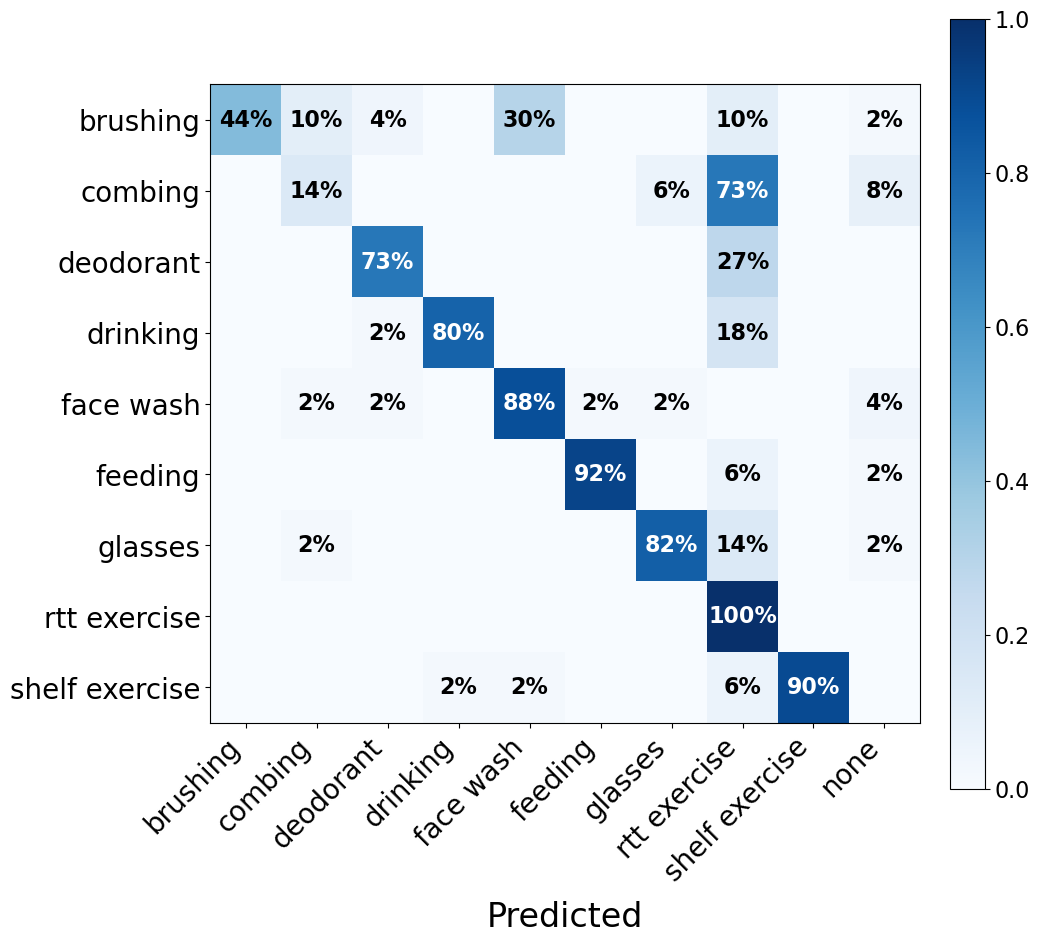

Total counts: 452


(array([[22,  5,  2,  0, 15,  0,  0,  5,  0,  1],
        [ 0,  7,  0,  0,  0,  0,  3, 37,  0,  4],
        [ 0,  0, 37,  0,  0,  0,  0, 14,  0,  0],
        [ 0,  0,  1, 41,  0,  0,  0,  9,  0,  0],
        [ 0,  1,  1,  0, 44,  1,  1,  0,  0,  2],
        [ 0,  0,  0,  0,  0, 46,  0,  3,  0,  1],
        [ 0,  1,  0,  0,  0,  0, 41,  7,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 50,  0,  0],
        [ 0,  0,  0,  1,  1,  0,  0,  3, 44,  0]]),
 ['brushing',
  'combing',
  'deodorant',
  'drinking',
  'face wash',
  'feeding',
  'glasses',
  'rtt exercise',
  'shelf exercise',
  'none'])

In [16]:
plot_confusion_matrix_from_df(
    df_stroke,
    true_col="activity",
    pred_col="pred_activity",
    label_order=exercises + ['none'],
    normalize=True,
    title="Stroke",
    rotate_xticks=45,
    save_fig="identification_cm_qwen2_5_vl_7b_tuned_stroke.pdf",
    show_ylabel=False,
    show_colorbar=True,
)

In [17]:
df_control['patient'].unique()

array(['C00011', 'C00012', 'C00019', 'C00022', 'C00023', 'C00024',
       'C00025', 'C00026', 'C00027', 'C00028', 'C00029', 'C00030',
       'C00031', 'C00032', 'C0004', 'C0005', 'C0007', 'C0009'],
      dtype=object)

In [18]:
len(df_control['patient'].unique())

18

In [19]:
df_control[df_control['activity'] == 'combing']['patient'].unique()

array(['C00011', 'C00012', 'C00019', 'C00022', 'C00023', 'C00024',
       'C00025', 'C00026', 'C00027', 'C00028', 'C00029', 'C00030',
       'C00031', 'C0004', 'C0005', 'C0007', 'C0009'], dtype=object)

In [20]:
set(df_control['patient'].unique()) - set(df_control[df_control['activity'] == 'combing']['patient'].unique())

{'C00032'}

In [21]:
# Chi-square tests: control vs stroke
# (a) overall 2x2 chi-square of homogeneity
# (b) per-activity 2x2 chi-square (or Fisher's exact if any cell < 5), Holm-Bonferroni corrected
# Caveat: videos are nested within ~35 subjects; chi-square treats them as
# independent, so it slightly overstates significance. Read as descriptive.
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

_df = dfs_tuned["qwen2_5_vl_7b"].copy()
_df["correct"] = (_df["pred_activity"] == _df["activity"]).astype(int)


def _two_by_two(sub: pd.DataFrame) -> np.ndarray:
    c = sub[~sub["stroke"]]
    s = sub[sub["stroke"]]
    return np.array(
        [
            [int(c["correct"].sum()), int((1 - c["correct"]).sum())],
            [int(s["correct"].sum()), int((1 - s["correct"]).sum())],
        ]
    )


def _run(table: np.ndarray):
    if (table < 5).any():
        _, p = fisher_exact(table)
        return p, "Fisher"
    chi2, p, _, _ = chi2_contingency(table, correction=False)
    return p, f"chi2={chi2:.2f}"


# (a) overall
tab_all = _two_by_two(_df)
p_all, m_all = _run(tab_all)
acc_c_all = tab_all[0, 0] / tab_all[0].sum()
acc_s_all = tab_all[1, 0] / tab_all[1].sum()

# (b) per-activity
rows = []
for act in exercises:
    sub = _df[_df["activity"] == act]
    tab = _two_by_two(sub)
    p, method = _run(tab)
    rows.append(
        {
            "activity": act,
            "n_c": int(tab[0].sum()),
            "acc_c": tab[0, 0] / tab[0].sum() if tab[0].sum() else float("nan"),
            "n_s": int(tab[1].sum()),
            "acc_s": tab[1, 0] / tab[1].sum() if tab[1].sum() else float("nan"),
            "p_raw": p,
            "method": method,
        }
    )

per_act = pd.DataFrame(rows)
_, p_holm, _, _ = multipletests(per_act["p_raw"].values, method="holm")
per_act["p_holm"] = p_holm


def _fmt_p(p: float) -> str:
    if p < 1e-3:
        return r"$<$0.001"
    return f"{p:.3f}"


print("\\begin{tabular}{l r r r r l l}")
print("\\toprule")
print("Activity & $n_c$ & Acc$_c$ & $n_s$ & Acc$_s$ & $p$ (raw) & $p$ (Holm) \\\\")
print("\\midrule")
print(
    f"Overall & {tab_all[0].sum()} & {acc_c_all:.3f} & "
    f"{tab_all[1].sum()} & {acc_s_all:.3f} & {_fmt_p(p_all)} & --- \\\\"
)
print("\\midrule")
for _, r in per_act.iterrows():
    print(
        f"{r['activity']} & {r['n_c']} & {r['acc_c']:.3f} & "
        f"{r['n_s']} & {r['acc_s']:.3f} & {_fmt_p(r['p_raw'])} & {_fmt_p(r['p_holm'])} \\\\"
    )
print("\\bottomrule")
print("\\end{tabular}")
print()
print("Per-activity methods (Fisher used when any cell < 5):")
for _, r in per_act.iterrows():
    print(f"  {r['activity']:>16s}  {r['method']}")


\begin{tabular}{l r r r r l l}
\toprule
Activity & $n_c$ & Acc$_c$ & $n_s$ & Acc$_s$ & $p$ (raw) & $p$ (Holm) \\
\midrule
Overall & 188 & 0.872 & 452 & 0.735 & $<$0.001 & --- \\
\midrule
brushing & 17 & 0.529 & 50 & 0.440 & 0.523 & 1.000 \\
combing & 17 & 0.471 & 51 & 0.137 & 0.004 & 0.037 \\
deodorant & 17 & 0.882 & 51 & 0.725 & 0.322 & 1.000 \\
drinking & 17 & 0.882 & 51 & 0.804 & 0.716 & 1.000 \\
face wash & 17 & 0.941 & 50 & 0.880 & 0.669 & 1.000 \\
feeding & 17 & 1.000 & 50 & 0.920 & 0.565 & 1.000 \\
glasses & 17 & 0.941 & 50 & 0.820 & 0.432 & 1.000 \\
rtt exercise & 36 & 1.000 & 50 & 1.000 & 1.000 & 1.000 \\
shelf exercise & 33 & 0.970 & 49 & 0.898 & 0.393 & 1.000 \\
\bottomrule
\end{tabular}

Per-activity methods (Fisher used when any cell < 5):
          brushing  chi2=0.41
           combing  chi2=8.24
         deodorant  Fisher
          drinking  Fisher
         face wash  Fisher
           feeding  Fisher
           glasses  Fisher
      rtt exercise  Fisher
    shelf exerc

In [22]:
# Plain-text version of the chi-square table (copy-paste friendly).
# Assumes the previous cell has already populated `tab_all`, `acc_c_all`,
# `acc_s_all`, `p_all`, and `per_act`.
def _fmt_p_txt(p: float) -> str:
    if p < 1e-3:
        return "<0.001"
    return f"{p:.3f}"


_header = f"{'Activity':<16}{'n_c':>6}{'Acc_c':>9}{'n_s':>7}{'Acc_s':>9}{'p (raw)':>11}{'p (Holm)':>11}"
_sep = "-" * len(_header)
print(_header)
print(_sep)
print(
    f"{'Overall':<16}{tab_all[0].sum():>6d}{acc_c_all:>9.3f}"
    f"{tab_all[1].sum():>7d}{acc_s_all:>9.3f}"
    f"{_fmt_p_txt(p_all):>11}{'---':>11}"
)
print(_sep)
for _, r in per_act.iterrows():
    print(
        f"{r['activity']:<16}{r['n_c']:>6d}{r['acc_c']:>9.3f}"
        f"{r['n_s']:>7d}{r['acc_s']:>9.3f}"
        f"{_fmt_p_txt(r['p_raw']):>11}{_fmt_p_txt(r['p_holm']):>11}"
    )


Activity           n_c    Acc_c    n_s    Acc_s    p (raw)   p (Holm)
---------------------------------------------------------------------
Overall            188    0.872    452    0.735     <0.001        ---
---------------------------------------------------------------------
brushing            17    0.529     50    0.440      0.523      1.000
combing             17    0.471     51    0.137      0.004      0.037
deodorant           17    0.882     51    0.725      0.322      1.000
drinking            17    0.882     51    0.804      0.716      1.000
face wash           17    0.941     50    0.880      0.669      1.000
feeding             17    1.000     50    0.920      0.565      1.000
glasses             17    0.941     50    0.820      0.432      1.000
rtt exercise        36    1.000     50    1.000      1.000      1.000
shelf exercise      33    0.970     49    0.898      0.393      1.000


In [ ]:
# Stratified accuracy: Control vs Mild vs Moderate vs Severe.
# Omnibus 4x2 chi-square (correct/incorrect x stratum) + pairwise vs Control
# (Holm-corrected). Severity labels from data/utils_strokerehab.py.
from data.utils_strokerehab import MILD_SUBJECTS, MODERATE_SUBJECTS, SEVERE_SUBJECTS

_mild = set(MILD_SUBJECTS.split(","))
_mod = set(MODERATE_SUBJECTS.split(","))
_sev = set(SEVERE_SUBJECTS.split(","))


def _severity(pid: str) -> str:
    if not isinstance(pid, str) or not pid.lower().startswith("s"):
        return "control"
    if pid in _mild:
        return "mild"
    if pid in _mod:
        return "moderate"
    if pid in _sev:
        return "severe"
    return "unknown"


_df_strat = dfs_tuned["qwen2_5_vl_7b"].copy()
_df_strat["correct"] = (_df_strat["pred_activity"] == _df_strat["activity"]).astype(int)
_df_strat["stratum"] = _df_strat["patient"].map(_severity)

_unknown = _df_strat[_df_strat["stratum"] == "unknown"]["patient"].unique()
if len(_unknown):
    print(f"WARNING: {len(_unknown)} stroke patient(s) not in any severity list: {list(_unknown)}")

_order = ["control", "mild", "moderate", "severe"]
_strat_df = _df_strat[_df_strat["stratum"].isin(_order)]

# Per-stratum N + accuracy
_rows = []
for s in _order:
    sub = _strat_df[_strat_df["stratum"] == s]
    n = len(sub)
    n_pat = sub["patient"].nunique()
    acc = sub["correct"].mean() if n else float("nan")
    _rows.append({"stratum": s, "n_patients": n_pat, "n_videos": n, "acc": acc})

# Omnibus 4x2 chi-square
_table = np.array(
    [
        [
            int(_strat_df[_strat_df["stratum"] == s]["correct"].sum()),
            int((1 - _strat_df[_strat_df["stratum"] == s]["correct"]).sum()),
        ]
        for s in _order
    ]
)
_chi2_omni, _p_omni, _dof_omni, _ = chi2_contingency(_table, correction=False)

# Pairwise: control vs each severity
_pair_p_raw = []
for s in _order[1:]:
    sub = _strat_df[_strat_df["stratum"].isin(["control", s])]
    tab = np.array(
        [
            [
                int(sub[sub["stratum"] == "control"]["correct"].sum()),
                int((1 - sub[sub["stratum"] == "control"]["correct"]).sum()),
            ],
            [
                int(sub[sub["stratum"] == s]["correct"].sum()),
                int((1 - sub[sub["stratum"] == s]["correct"]).sum()),
            ],
        ]
    )
    if (tab < 5).any():
        _, p = fisher_exact(tab)
    else:
        _, p, _, _ = chi2_contingency(tab, correction=False)
    _pair_p_raw.append(p)
_, _pair_p_holm, _, _ = multipletests(_pair_p_raw, method="holm")


def _fmt_p_txt(p: float) -> str:
    if p < 1e-3:
        return "<0.001"
    return f"{p:.3f}"


_header = f"{'Stratum':<12}{'n_pat':>7}{'n_vid':>7}{'Acc':>9}{'p vs Ctrl (raw)':>18}{'p vs Ctrl (Holm)':>19}"
_sep = "-" * len(_header)
print(_header)
print(_sep)
for i, r in enumerate(_rows):
    if r["stratum"] == "control":
        p_raw_str = "---"
        p_holm_str = "---"
    else:
        idx = _order.index(r["stratum"]) - 1
        p_raw_str = _fmt_p_txt(_pair_p_raw[idx])
        p_holm_str = _fmt_p_txt(_pair_p_holm[idx])
    print(
        f"{r['stratum']:<12}{r['n_patients']:>7d}{r['n_videos']:>7d}"
        f"{r['acc']:>9.3f}{p_raw_str:>18}{p_holm_str:>19}"
    )
print(_sep)
print(
    f"Omnibus 4x2 chi-square: chi2={_chi2_omni:.2f}, "
    f"df={_dof_omni}, p={_fmt_p_txt(_p_omni)}"
)


In [ ]:
# Final paper figure: tuned-prompt confusion matrices, Control vs Stroke.
# Reuses plot_confusion_matrix_from_df (defined above) and recomputes the
# Control / Stroke splits so this cell is self-contained.
_df_t = dfs_tuned["qwen2_5_vl_7b"]
df_control = _df_t[~_df_t["stroke"]]
df_stroke  = _df_t[ _df_t["stroke"]]
print(f"Control videos: {len(df_control)}  |  Stroke videos: {len(df_stroke)}")

plot_confusion_matrix_from_df(
    df_control,
    true_col="activity",
    pred_col="pred_activity",
    label_order=exercises + ["none"],
    normalize=True,
    title="Control",
    rotate_xticks=45,
    save_fig="identification_cm_qwen2_5_vl_7b_tuned_control.pdf",
    show_ylabel=True,
    show_colorbar=False,
)
plot_confusion_matrix_from_df(
    df_stroke,
    true_col="activity",
    pred_col="pred_activity",
    label_order=exercises + ["none"],
    normalize=True,
    title="Stroke",
    rotate_xticks=45,
    save_fig="identification_cm_qwen2_5_vl_7b_tuned_stroke.pdf",
    show_ylabel=False,
    show_colorbar=True,
)
